# 202235203 고수호
# **7week - wine.csv 데이터에 대한 Pytorch regression**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from torchsummary import summary
import numpy as np

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/7week/wine.csv')
data

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [ ]:
# 1. 데이터 준비 (Alcohol을 타겟으로 설정)
X = data.drop('Alcohol', axis=1).values
y = data['Alcohol'].values.reshape(-1, 1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 텐서 변환 (회귀에서는 타겟도 FloatTensor여야 함)
X_train_ts = torch.FloatTensor(X_train)
y_train_ts = torch.FloatTensor(y_train)
X_test_ts = torch.FloatTensor(X_test)
y_test_ts = torch.FloatTensor(y_test)

In [ ]:
train_loader = DataLoader(TensorDataset(X_train_ts, y_train_ts), batch_size=16, shuffle=True)

In [ ]:
# 2. 회귀 모델 정의
class WineRegression(nn.Module):
    def __init__(self, input_dim):
        super(WineRegression, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1) # 출력을 1개로 설정

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x) # 활성화 함수 없이 수치 그대로 출력

model = WineRegression(X.shape[1])

In [ ]:
# 3. 손실 함수와 옵티마이저 (회귀용)
criterion = nn.MSELoss() # Mean Squared Error
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# 4. 학습 루프
num_epochs = 100
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    batch_loss = 0
    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        batch_loss += loss.item()

    train_losses.append(batch_loss / len(train_loader))
    # 테스트 데이터에 대한 MSE 계산
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_ts)
        test_mse = criterion(test_preds, y_test_ts)
        test_losses.append(test_mse.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Train MSE: {train_losses[-1]:.4f}, Test MSE: {test_losses[-1]:.4f}")

Epoch [10/100], Train MSE: 2.1722, Test MSE: 1.5194
Epoch [20/100], Train MSE: 1.9394, Test MSE: 1.3402
Epoch [30/100], Train MSE: 2.1588, Test MSE: 1.3046
Epoch [40/100], Train MSE: 1.6708, Test MSE: 1.3617
Epoch [50/100], Train MSE: 1.6889, Test MSE: 1.6970
Epoch [60/100], Train MSE: 2.3520, Test MSE: 2.7399
Epoch [70/100], Train MSE: 1.5998, Test MSE: 1.5760
Epoch [80/100], Train MSE: 1.4283, Test MSE: 1.3680
Epoch [90/100], Train MSE: 1.7016, Test MSE: 2.2863
Epoch [100/100], Train MSE: 1.2848, Test MSE: 0.8963


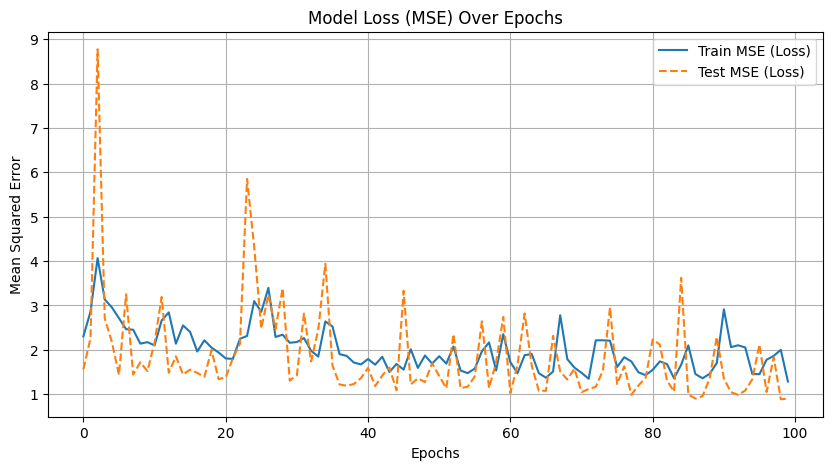

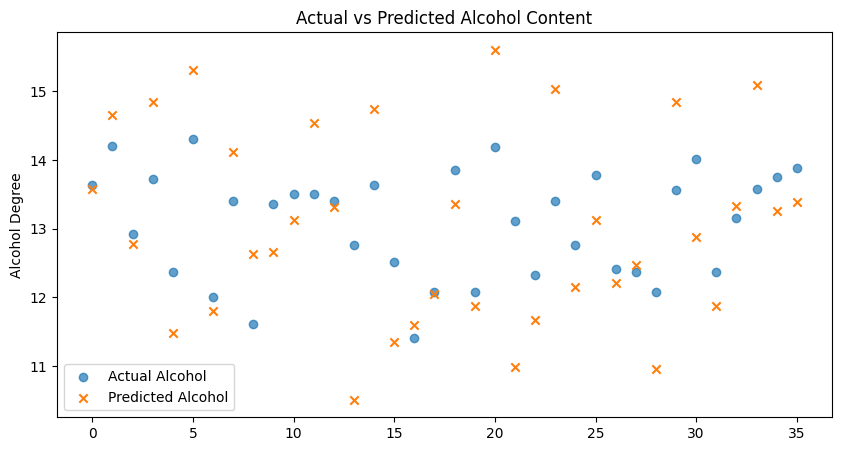

In [ ]:
# 5. 시각화 코드
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE (Loss)')
plt.plot(test_losses, label='Test MSE (Loss)', linestyle='--')
plt.title('Model Loss (MSE) Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# 실제값 vs 예측값 비교 시각화 (모델 성능 확인용)
model.eval()
with torch.no_grad():
    final_preds = model(X_test_ts).numpy()

plt.figure(figsize=(10, 5))
plt.scatter(range(len(y_test)), y_test, label='Actual Alcohol', alpha=0.7)
plt.scatter(range(len(final_preds)), final_preds, label='Predicted Alcohol', marker='x')
plt.title('Actual vs Predicted Alcohol Content')
plt.ylabel('Alcohol Degree')
plt.legend()
plt.show()